In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated, Literal 
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver

In [2]:
load_dotenv()

llm = ChatOpenAI()

In [3]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [4]:
def generate_joke(state: JokeState):
    
    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content
    return {"joke": response}

In [5]:
def generate_explanation(state: JokeState):
    
    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content
    return {"explanation": response}

In [6]:
# Create our graph
graph = StateGraph(JokeState)

# add nodes to your graph
graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

# add edges to your graph
graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = MemorySaver()

# compile your graph 
workflow = graph.compile(checkpointer=checkpointer)

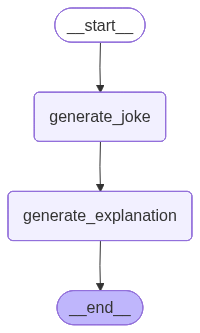

In [7]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [8]:
# Execute the workflow

config1 = {'configurable': {'thread_id': '1'}}
workflow.invoke({'topic': 'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the therapist?\n\nBecause it felt really saucy and needed to get things off its crust!',
 'explanation': 'This joke plays on the idea of a pizza having emotions and being able to feel "saucy" (which can mean feeling bold, confident, or daring). In this case, the pizza is personified as if it were a person with emotional issues that might need to be discussed with a therapist. The punchline humorously suggests that the pizza went to therapy because it needed to express its feelings and "get things off its crust" (similar to "get things off its chest", meaning to talk about something that is bothering you). Overall, the joke is a lighthearted and playful way to imagine a pizza seeking therapy for feeling "saucy."'}

In [9]:
workflow.get_state(config1) # final state value

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the therapist?\n\nBecause it felt really saucy and needed to get things off its crust!', 'explanation': 'This joke plays on the idea of a pizza having emotions and being able to feel "saucy" (which can mean feeling bold, confident, or daring). In this case, the pizza is personified as if it were a person with emotional issues that might need to be discussed with a therapist. The punchline humorously suggests that the pizza went to therapy because it needed to express its feelings and "get things off its crust" (similar to "get things off its chest", meaning to talk about something that is bothering you). Overall, the joke is a lighthearted and playful way to imagine a pizza seeking therapy for feeling "saucy."'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f143bc3-e0f2-6875-8002-585ec306dc41'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-

In [16]:
list(workflow.get_state_history(config1)) # entire history of states

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the therapist?\n\nBecause it felt really saucy and needed to get things off its crust!', 'explanation': 'This joke plays on the idea of a pizza having emotions and being able to feel "saucy" (which can mean feeling bold, confident, or daring). In this case, the pizza is personified as if it were a person with emotional issues that might need to be discussed with a therapist. The punchline humorously suggests that the pizza went to therapy because it needed to express its feelings and "get things off its crust" (similar to "get things off its chest", meaning to talk about something that is bothering you). Overall, the joke is a lighthearted and playful way to imagine a pizza seeking therapy for feeling "saucy."'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f143bc3-e0f2-6875-8002-585ec306dc41'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026

# Time Travel 

In [17]:
# 'checkpoint_id': '1f143bc3-b23f-628b-8000-f06170ff46ef' # entire history of states before the joke generation node 

workflow.get_state({'configurable': {'thread_id': '1'}, 'checkpoint_id': '1f143bc3-b23f-628b-8000-f06170ff46ef'}) # state value at the checkpoint before joke generation

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the therapist?\n\nBecause it felt really saucy and needed to get things off its crust!', 'explanation': 'This joke plays on the idea of a pizza having emotions and being able to feel "saucy" (which can mean feeling bold, confident, or daring). In this case, the pizza is personified as if it were a person with emotional issues that might need to be discussed with a therapist. The punchline humorously suggests that the pizza went to therapy because it needed to express its feelings and "get things off its crust" (similar to "get things off its chest", meaning to talk about something that is bothering you). Overall, the joke is a lighthearted and playful way to imagine a pizza seeking therapy for feeling "saucy."'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f143bc3-e0f2-6875-8002-585ec306dc41'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-

In [18]:
workflow.invoke(None, {'configurable': {'thread_id': '1'}, 'checkpoint_id': '1f143bc3-b23f-628b-8000-f06170ff46ef'}) # resume from checkpoint before joke generation

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the bar?\n\nHe wanted to get sauced!',
 'explanation': 'This joke plays on the word "sauced," which can mean both being covered in a sauce and being intoxicated. In this case, the pizza "wanted to get sauced" by going to the bar to potentially be covered in sauce from toppings, but it also implies that the pizza wanted to get drunk, or "sauced," like many people do at bars. It\'s a clever play on words that combines food humor with a common drinking expression.'}

In [19]:
list(workflow.get_state_history(config1)) # entire history of states

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the bar?\n\nHe wanted to get sauced!', 'explanation': 'This joke plays on the word "sauced," which can mean both being covered in a sauce and being intoxicated. In this case, the pizza "wanted to get sauced" by going to the bar to potentially be covered in sauce from toppings, but it also implies that the pizza wanted to get drunk, or "sauced," like many people do at bars. It\'s a clever play on words that combines food humor with a common drinking expression.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f143be2-81b0-6cc5-8003-d076b2bd9bcf'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-04-29T11:25:42.090438+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f143be2-7015-6e9e-8002-ee9d27cc6563'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza 

# Updating State

In [21]:
workflow.update_state({'configurable': {'thread_id': '1'}, 'checkpoint_id': '1f143bc3-b23f-628b-8000-f06170ff46ef', 'checkpoint_ns': ''}, {'topic': 'samosa'}) # update state at checkpoint to change the topic to pasta

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f143beb-644a-670f-8001-a75f7dd4f8c4'}}

In [22]:
list(workflow.get_state_history(config1)) # entire history of states

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f143beb-644a-670f-8001-a75f7dd4f8c4'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-04-29T11:29:40.599550+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f143bc3-b23f-628b-8000-f06170ff46ef'}}, tasks=(PregelTask(id='82286b95-638f-db7b-23a0-fc4f76cc0c87', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the bar?\n\nHe wanted to get sauced!', 'explanation': 'This joke plays on the word "sauced," which can mean both being covered in a sauce and being intoxicated. In this case, the pizza "wanted to get sauced" by going to the bar to potentially be covered in sauce from toppings, but it also implies that the

In [23]:
workflow.invoke(None, {'configurable': {'thread_id': '1'}, 'checkpoint_id': '1f143beb-644a-670f-8001-a75f7dd4f8c4'}) # resume from checkpoint before joke generation

{'topic': 'samosa',
 'joke': 'Why did the samosa go to the party? Because it wanted to be a little "triangular"!',
 'explanation': 'This joke plays on the shape of a samosa, which is triangular. The humor comes from the play on words with the term "triangular." In this context, the samosa went to the party because it wanted to "be a little triangular," meaning it wanted to fit in and be a part of the festivities. Overall, the joke is light-hearted and plays on the unique shape of a samosa.'}

In [24]:
list(workflow.get_state_history(config1)) # entire history of states

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to the party? Because it wanted to be a little "triangular"!', 'explanation': 'This joke plays on the shape of a samosa, which is triangular. The humor comes from the play on words with the term "triangular." In this context, the samosa went to the party because it wanted to "be a little triangular," meaning it wanted to fit in and be a part of the festivities. Overall, the joke is light-hearted and plays on the unique shape of a samosa.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f143bee-8099-614a-8003-43903f0b75b5'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-04-29T11:31:04.098407+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f143bee-64a7-69c4-8002-a609c1bc7baa'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to the party? Becau

In [14]:
config2 = {'configurable': {'thread_id': '2'}}
workflow.invoke({'topic': 'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the pasta take up gardening?\nBecause it wanted to become a spaghetti squash!',
 'explanation': 'This joke is a play on words, combining the idea of pasta (such as spaghetti) with the vegetable spaghetti squash. Spaghetti squash is a type of vegetable that, when cooked, can resemble the texture and shape of spaghetti noodles. The joke suggests that the pasta decided to take up gardening in order to transform into a spaghetti squash, playing on the idea of the pasta literally becoming a different type of food.'}

In [15]:
workflow.get_state(config2) # final state value

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the pasta take up gardening?\nBecause it wanted to become a spaghetti squash!', 'explanation': 'This joke is a play on words, combining the idea of pasta (such as spaghetti) with the vegetable spaghetti squash. Spaghetti squash is a type of vegetable that, when cooked, can resemble the texture and shape of spaghetti noodles. The joke suggests that the pasta decided to take up gardening in order to transform into a spaghetti squash, playing on the idea of the pasta literally becoming a different type of food.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f141fd3-a6e4-6f48-8002-699a8bc624ca'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-27T05:52:08.803469+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f141fd3-9553-629b-8001-6eb27ff05c83'}}, tasks=(), interrupts=())

In [16]:
list(workflow.get_state_history(config2)) # entire history of states

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the pasta take up gardening?\nBecause it wanted to become a spaghetti squash!', 'explanation': 'This joke is a play on words, combining the idea of pasta (such as spaghetti) with the vegetable spaghetti squash. Spaghetti squash is a type of vegetable that, when cooked, can resemble the texture and shape of spaghetti noodles. The joke suggests that the pasta decided to take up gardening in order to transform into a spaghetti squash, playing on the idea of the pasta literally becoming a different type of food.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f141fd3-a6e4-6f48-8002-699a8bc624ca'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-27T05:52:08.803469+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f141fd3-9553-629b-8001-6eb27ff05c83'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pa